# El carbono de 3I/ATLAS es casi el doble de primitivo que el del Sol

Y ese solo dato lo delata: no nació con nuestro sistema solar, sino con estrellas mucho más viejas.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** *Isotopic evidence for a cold and distant origin of 3I/ATLAS* — Cordiner et al. (2026), *Nature*
**DOI:** [10.1038/s41586-026-10771-6](https://doi.org/10.1038/s41586-026-10771-6)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-06-22-3i-atlas-isotopos-origen-frio/notebook.ipynb)

*Video: [Pendiente]*

## Un visitante de otra estrella

3I/ATLAS es apenas el **tercer objeto interestelar** que hemos atrapado cruzando el sistema solar. No es un cometa nuestro: entró de fuera y volverá a salir. Eso lo vuelve especial — es una muestra directa del hielo con que se construyen planetas alrededor de *otras* estrellas.

Con el telescopio JWST, un equipo midió la huella química de su gas: cuánto carbono-13 lleva frente al carbono-12, y cuánto deuterio (hidrógeno pesado) esconde su agua. Esas dos proporciones funcionan como un reloj y un termómetro del lugar donde nació. Veamos qué marcan.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
C12C13_SOLAR   = 89        # 12C/13C del Sol (Ayres et al. 2013)
BANDA_3I_MIN   = 141       # banda comun CO2 ∩ CO de 3I/ATLAS (JWST)
BANDA_3I_MAX   = 172
COLOR_DATOS       = '#2563EB'   # azul CaM — 3I/ATLAS (JWST)
COLOR_ALERTA      = '#DC2626'   # rojo — el contraste
COLOR_REFERENCIA  = '#D97706'   # ámbar — Sol y estrellas
COLOR_SECUNDARIO  = '#059669'   # emerald — medida independiente (VLT)
COLOR_VIEJO       = '#7C3AED'   # violeta — pistas de "época distante"
FUENTE = 'Fuente: Cordiner et al. (2026), Nature | Datos: abstract + Supplementary (MOESM1)'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Estilo CaM (local -> /tmp inyectado -> GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Carga de los CSV destilados del paper + Supplementary
iso   = pd.read_csv('datos/isotopos_12c13c_comparacion.csv')
grad  = pd.read_csv('datos/gradiente_galactico_12c13c.csv')
evid  = pd.read_csv('datos/evidencia_origen.csv')
dh    = pd.read_csv('datos/dh_astration_tiempo.csv')

print(f"Isotopos comparados : {len(iso)} objetos")
print(f"Gradiente galactico : {len(grad)} radios (0-16 kpc)")
print(f"Lineas de evidencia : {len(evid)}")
print(f"\n12C/13C del Sol            : {C12C13_SOLAR}")
print(f"Banda de 3I/ATLAS (CO2/CO): {BANDA_3I_MIN}-{BANDA_3I_MAX}")
print(f"Cociente 3I/ATLAS / Sol   : {166/C12C13_SOLAR:.2f}x (CO2 central)")

Isotopos comparados : 5 objetos
Gradiente galactico : 33 radios (0-16 kpc)
Lineas de evidencia : 8

12C/13C del Sol            : 89
Banda de 3I/ATLAS (CO2/CO): 141-172
Cociente 3I/ATLAS / Sol   : 1.87x (CO2 central)


Pongamos las medidas una al lado de la otra.

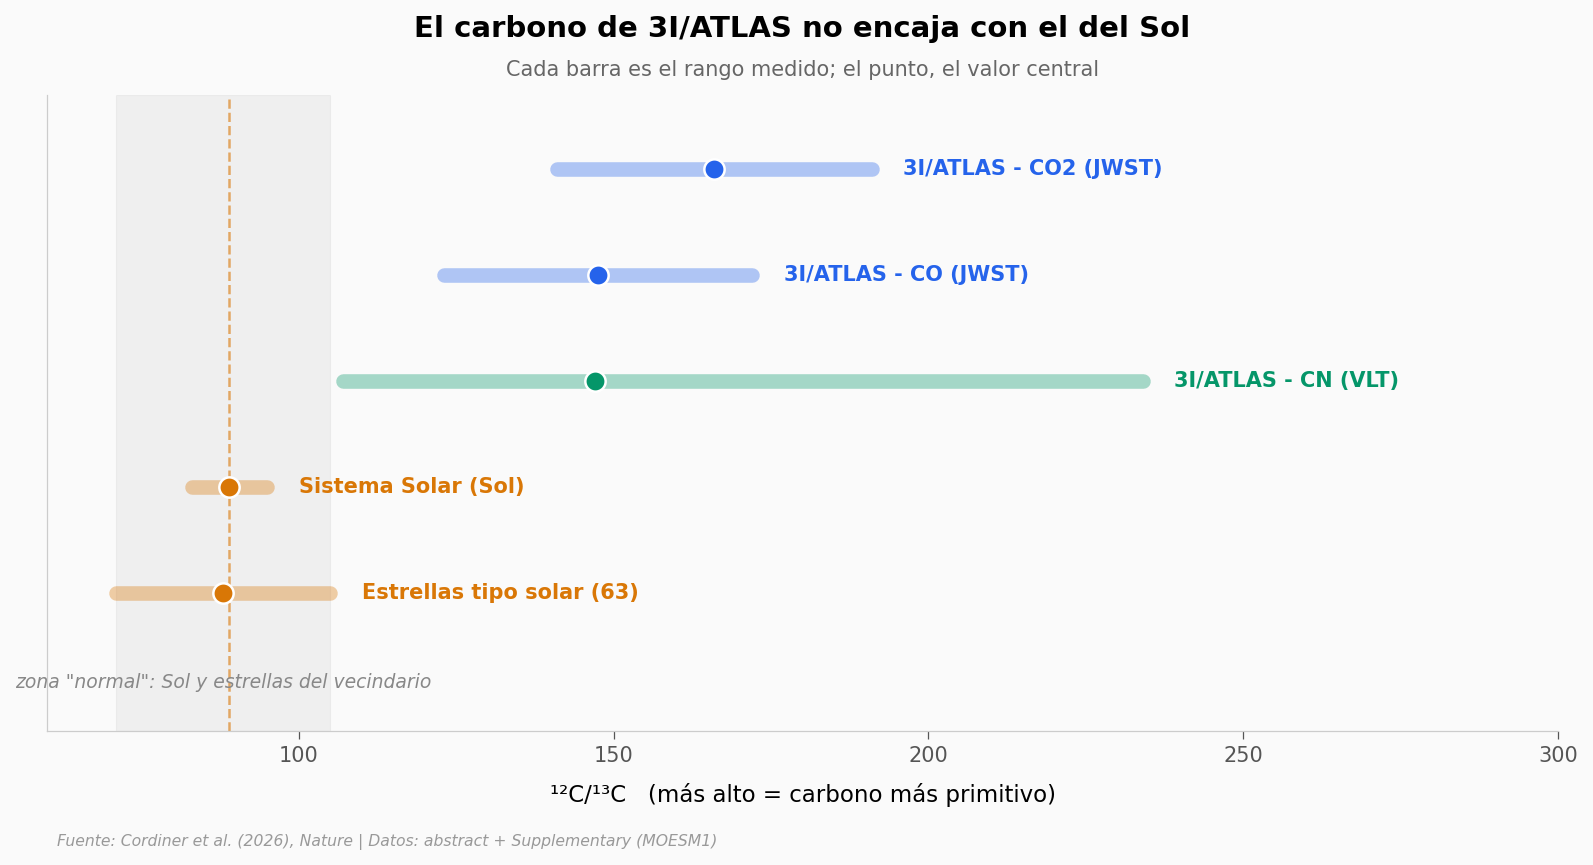

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# (nombre, central, lo, hi, color) — referencias abajo, 3I/ATLAS arriba
rows = [
    ('Estrellas tipo solar (63)', 88.0,  71, 105, COLOR_REFERENCIA),
    ('Sistema Solar (Sol)',       89.0,  83,  95, COLOR_REFERENCIA),
    ('3I/ATLAS - CN (VLT)',      147.0, 107, 234, COLOR_SECUNDARIO),
    ('3I/ATLAS - CO (JWST)',     147.5, 123, 172, COLOR_DATOS),
    ('3I/ATLAS - CO2 (JWST)',    166.0, 141, 191, COLOR_DATOS),
]

# Franja "normal" de referencia (Sol + estrellas cercanas)
ax.axvspan(71, 105, color='#BBBBBB', alpha=0.16, zorder=0)

for i, (name, c, lo, hi, color) in enumerate(rows):
    ax.plot([lo, hi], [i, i], color=color, lw=7, alpha=0.35,
            solid_capstyle='round', zorder=3)
    ax.scatter([c], [i], color=color, s=95, zorder=5,
               edgecolors='white', linewidths=1.2)
    ax.text(hi + 5, i, name, va='center', ha='left',
            fontsize=10, color=color, fontweight='bold')

ax.axvline(C12C13_SOLAR, color=COLOR_REFERENCIA, lw=1.2, ls='--', alpha=0.6, zorder=1)
ax.text(88, -0.9, 'zona "normal": Sol y estrellas del vecindario',
        fontsize=9, color='#888888', ha='center', style='italic')

ax.set_yticks([])
ax.set_xlim(60, 300)
ax.set_ylim(-1.3, len(rows) - 0.3)
ax.set_xlabel('\u00b9\u00b2C/\u00b9\u00b3C   (m\u00e1s alto = carbono m\u00e1s primitivo)', fontsize=11)
ax.set_title('El carbono de 3I/ATLAS no encaja con el del Sol',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada barra es el rango medido; el punto, el valor central',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_isotopos.png', dpi=200, bbox_inches='tight')
plt.show()

El Sol y sus 63 vecinas se apiñan entre 71 y 105. 3I/ATLAS vive en otro barrio: su carbono ronda 147–166, casi el doble. Y no es una sola medida caprichosa — JWST lo ve en el CO₂ **y** en el CO, y un instrumento distinto (el VLT, midiendo CN) cae en la misma franja. Tres moléculas, dos telescopios, la misma respuesta.

¿Por qué importa "más carbono-12 que carbono-13"? Porque el carbono-13 se fabrica con el tiempo, dentro de generaciones sucesivas de estrellas. Poco carbono-13 es la firma de material **viejo**, cocinado cuando la galaxia todavía era químicamente pobre.

## ¿No habrá un rincón de la galaxia que sí produzca ese carbono?

Buena objeción. La proporción ¹²C/¹³C no es igual en toda la Vía Láctea: sube a medida que te alejas del centro. Así que preguntemos lo justo: ¿el borde de la galaxia *hoy* llega a los valores de 3I/ATLAS?

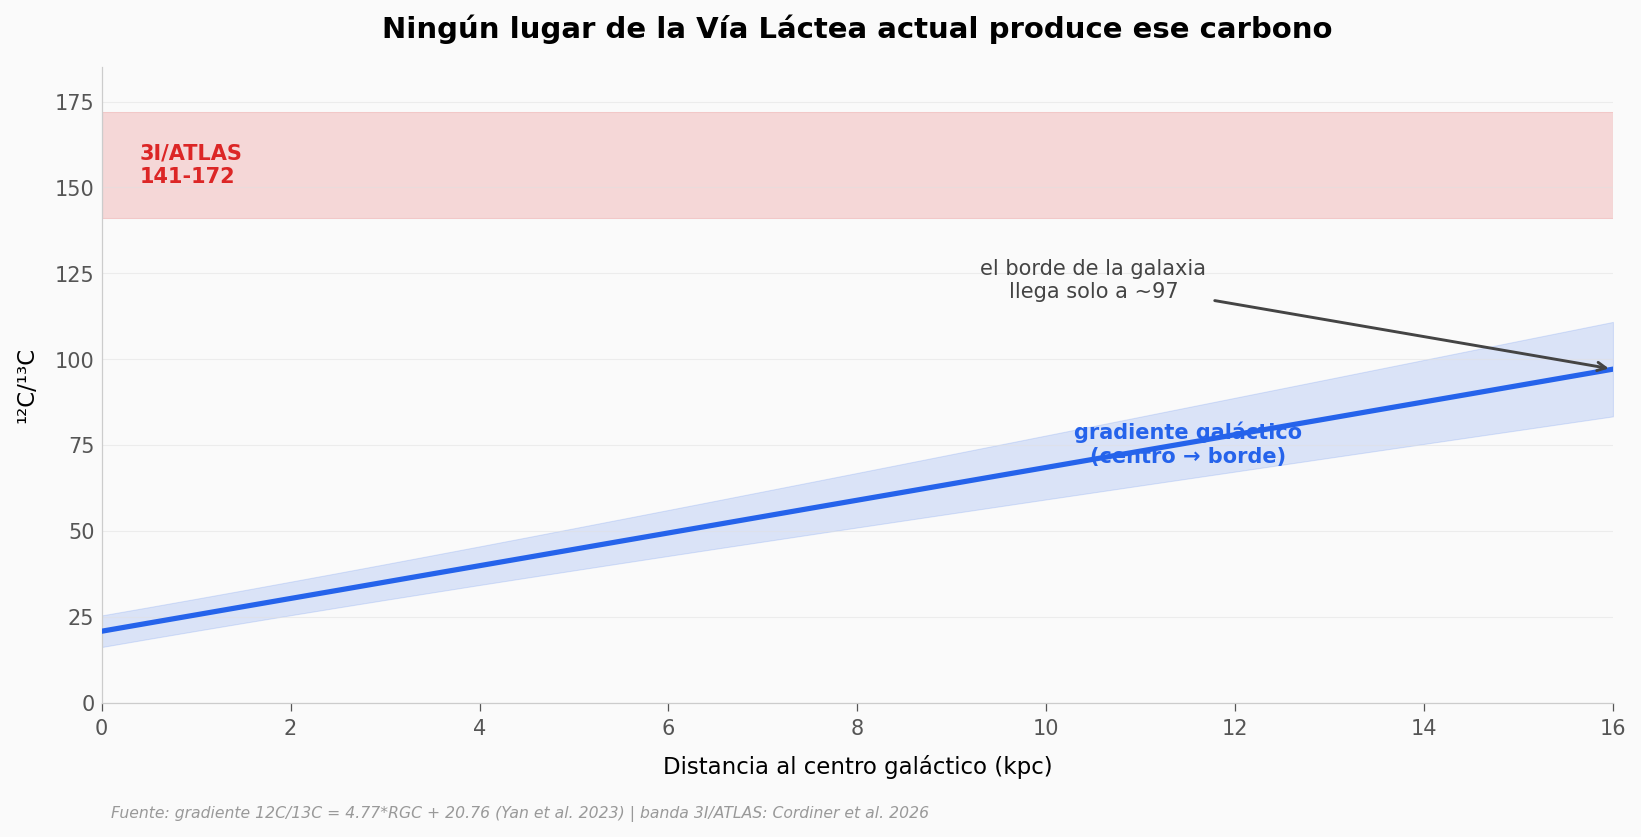

In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

ax.fill_between(grad['rgc_kpc'], grad['ratio_lo_1sigma'], grad['ratio_hi_1sigma'],
                color=COLOR_DATOS, alpha=0.15, zorder=1)
ax.plot(grad['rgc_kpc'], grad['ratio_12c13c'], color=COLOR_DATOS, lw=2.5, zorder=3)
ax.text(11.5, 70, 'gradiente gal\u00e1ctico\n(centro \u2192 borde)', color=COLOR_DATOS,
        fontsize=10, fontweight='bold', ha='center')

# Banda de 3I/ATLAS
ax.axhspan(BANDA_3I_MIN, BANDA_3I_MAX, color=COLOR_ALERTA, alpha=0.16, zorder=1)
ax.text(0.4, (BANDA_3I_MIN + BANDA_3I_MAX) / 2, '3I/ATLAS\n141-172',
        color=COLOR_ALERTA, fontweight='bold', fontsize=10, va='center')

gmax = grad['ratio_12c13c'].max()
ax.annotate(f'el borde de la galaxia\nllega solo a ~{gmax:.0f}',
            xy=(16, gmax), xytext=(10.5, 118), fontsize=10, color='#444444',
            ha='center', arrowprops=dict(arrowstyle='->', color='#444444', lw=1.4))

ax.set_xlim(0, 16)
ax.set_ylim(0, 185)
ax.set_xlabel('Distancia al centro gal\u00e1ctico (kpc)', fontsize=11)
ax.set_ylabel('\u00b9\u00b2C/\u00b9\u00b3C', fontsize=11)
ax.set_title('Ning\u00fan lugar de la V\u00eda L\u00e1ctea actual produce ese carbono',
             fontsize=14, fontweight='bold', pad=14)

fig.text(0.13, -0.03,
         'Fuente: gradiente 12C/13C = 4.77*RGC + 20.76 (Yan et al. 2023) | banda 3I/ATLAS: Cordiner et al. 2026',
         fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/gradiente_galactico.png', dpi=200, bbox_inches='tight')
plt.show()

## No es una sola pista, son ocho

El carbono es la más llamativa, pero el paper apila varias huellas independientes. Unas apuntan a que 3I/ATLAS se formó en un lugar **muy frío**; otras, a que nació en una **época muy lejana** de la historia galáctica. Veámoslas ordenadas por cuánto pesa cada una.

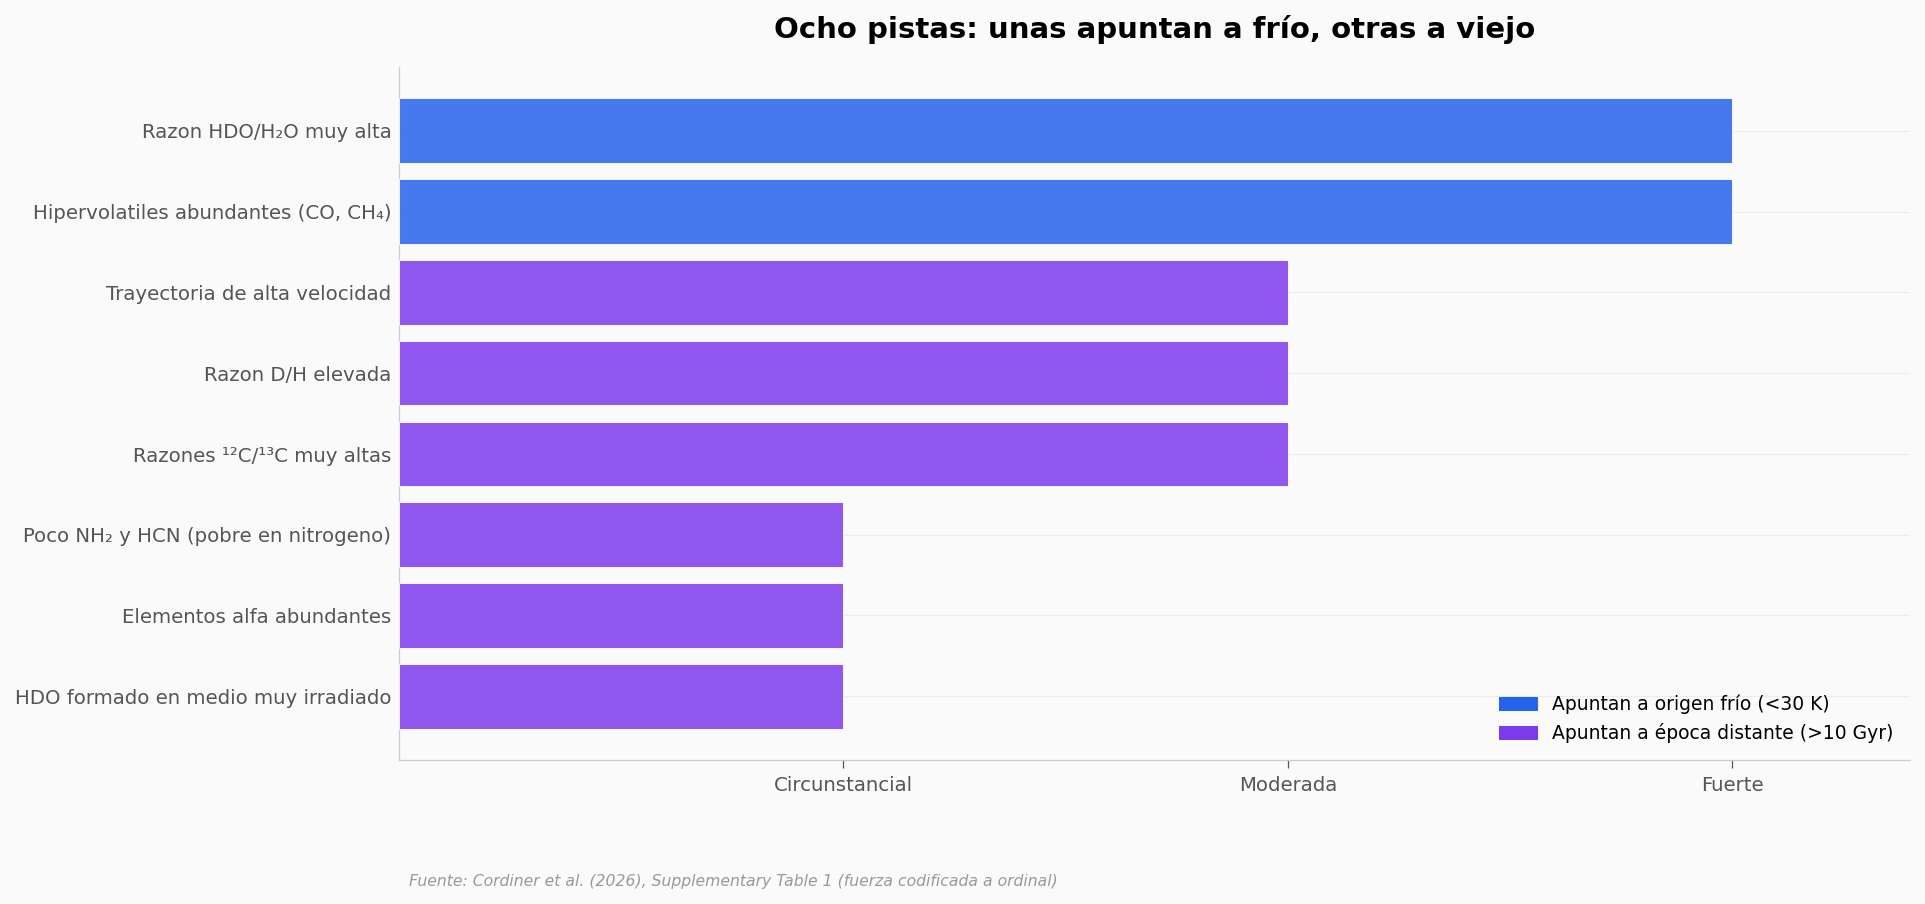

In [4]:
# Relabel con subindices Unicode para el eje
relabel = {
    'Grandes abundancias de hipervolatiles (CO, CH4)': 'Hipervolatiles abundantes (CO, CH\u2084)',
    'Razon HDO/H2O extremadamente alta': 'Razon HDO/H\u2082O muy alta',
    'Razones 12C/13C muy altas': 'Razones \u00b9\u00b2C/\u00b9\u00b3C muy altas',
    'Razon D/H elevada': 'Razon D/H elevada',
    'Formacion de HDO en ISM fuertemente irradiado': 'HDO formado en medio muy irradiado',
    'Elementos alfa abundantes': 'Elementos alfa abundantes',
    'Baja abundancia de NH2 y HCN': 'Poco NH\u2082 y HCN (pobre en nitrogeno)',
    'Trayectoria de alta velocidad': 'Trayectoria de alta velocidad',
}
cat_color = {'origen frio': COLOR_DATOS, 'epoca distante': COLOR_VIEJO}
cat_nice  = {'origen frio': 'Apuntan a origen fr\u00edo (<30 K)',
             'epoca distante': 'Apuntan a \u00e9poca distante (>10 Gyr)'}

ev = evid.sort_values(['categoria', 'fuerza_ord'], ascending=[True, True]).reset_index(drop=True)
y = np.arange(len(ev))
colors = [cat_color[c] for c in ev['categoria']]

fig, ax = plt.subplots(figsize=(13, 6))
ax.barh(y, ev['fuerza_ord'], color=colors, alpha=0.85, edgecolor='white', zorder=3)
ax.set_yticks(y)
ax.set_yticklabels([relabel[e] for e in ev['evidencia']], fontsize=9.5)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Circunstancial', 'Moderada', 'Fuerte'], fontsize=9.5)
ax.set_xlim(0, 3.4)

# Leyenda por categoria (inline, colores)
from matplotlib.patches import Patch
handles = [Patch(color=cat_color[k], label=cat_nice[k]) for k in cat_nice]
ax.legend(handles=handles, fontsize=9, loc='lower right', framealpha=0.9)

ax.set_title('Ocho pistas: unas apuntan a fr\u00edo, otras a viejo',
             fontsize=14, fontweight='bold', pad=14)
fig.text(0.13, -0.03,
         'Fuente: Cordiner et al. (2026), Supplementary Table 1 (fuerza codificada a ordinal)',
         fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/evidencia_origen.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué tan lejos, de verdad, está ese carbono?

Ya vimos que el gradiente galáctico no alcanza. Pongámoslo en una sola imagen: todas las proporciones que la galaxia *actual* puede exhibir, del centro al borde, contra el valor de 3I/ATLAS.

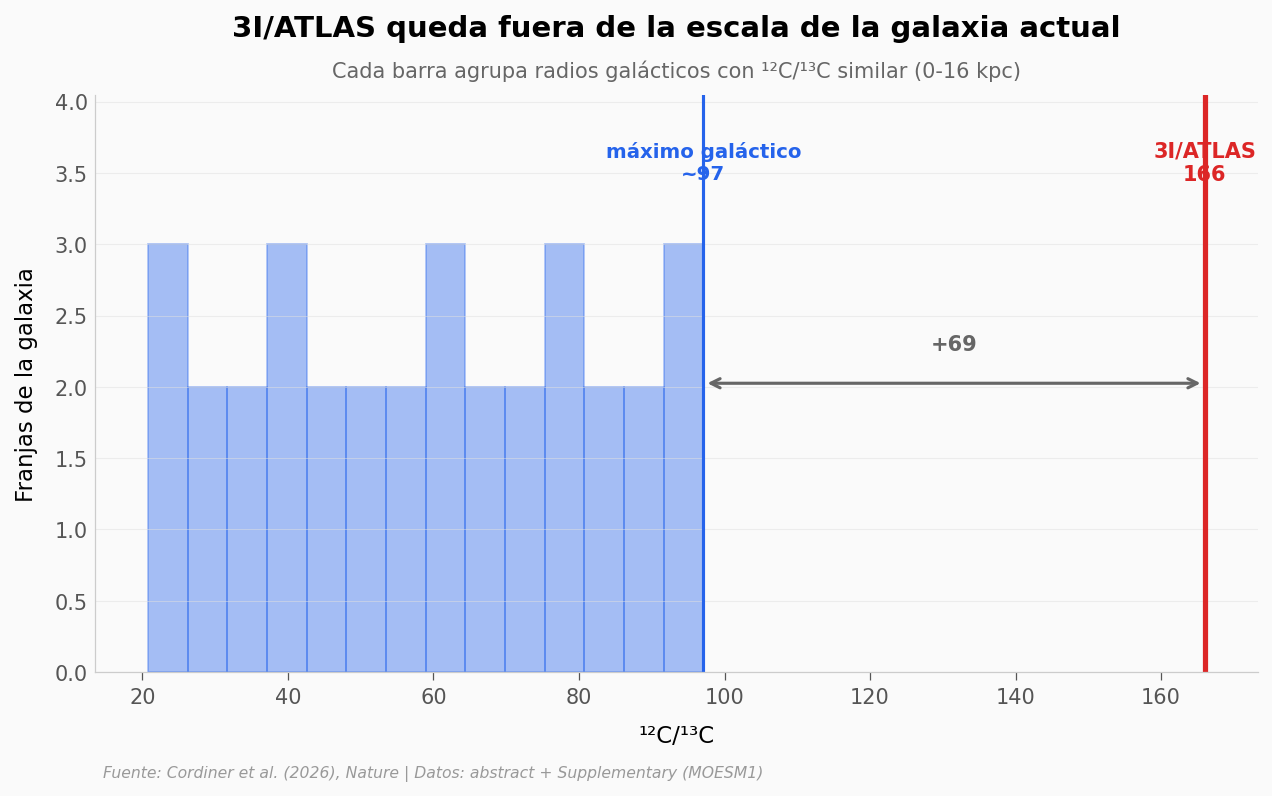

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

vals = grad['ratio_12c13c'].values  # 33 valores del gradiente (centro -> borde)
n, bins, patches = ax.hist(vals, bins=14, color=COLOR_DATOS, alpha=0.4,
                           edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.35
ax.set_ylim(0, y_max)

gmax = vals.max()
ax.axvline(gmax, color=COLOR_DATOS, lw=1.5)
ax.text(gmax, y_max * 0.92, f'm\u00e1ximo gal\u00e1ctico\n~{gmax:.0f}', color=COLOR_DATOS,
        fontsize=9.5, fontweight='bold', ha='center', va='top')

c3i = 166  # 3I/ATLAS, CO2 central
ax.axvline(c3i, color=COLOR_ALERTA, lw=2.5)
ax.text(c3i, y_max * 0.92, '3I/ATLAS\n166', color=COLOR_ALERTA,
        fontsize=10, fontweight='bold', ha='center', va='top')

ax.annotate('', xy=(c3i, y_max * 0.5), xytext=(gmax, y_max * 0.5),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((c3i + gmax) / 2, y_max * 0.55, f'+{c3i - gmax:.0f}', ha='center',
        va='bottom', fontsize=10, color='#666666', fontweight='bold')

ax.set_xlabel('\u00b9\u00b2C/\u00b9\u00b3C', fontsize=11)
ax.set_ylabel('Franjas de la galaxia', fontsize=11)
ax.set_title('3I/ATLAS queda fuera de la escala de la galaxia actual',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Cada barra agrupa radios gal\u00e1cticos con \u00b9\u00b2C/\u00b9\u00b3C similar (0-16 kpc)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/anomalia_histograma.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El ¹²C/¹³C de 3I/ATLAS (~147–166) casi duplica el solar (89) | ✅ | JWST en CO₂ (166) y CO (147,5); el VLT en CN (147) solapa la banda. Cociente CO₂/Sol = 1,87× |
| El gradiente galáctico actual no alcanza esa banda | ✅ | El máximo del gradiente (~97 a 16 kpc) queda por debajo del mínimo de 3I/ATLAS (141) |
| Su agua está muy enriquecida en deuterio | ✅ | HDO/H₂O = 0,98 % ± 0,06 (JWST), >1 orden de magnitud sobre cometas conocidos; ALMA da un límite consistente (>0,66 %) |
| Se formó a temperatura muy baja | ⚠️ | Los datos *indican* formación a ≲30 K (agua) y <25 K (hipervolátiles) — el paper lo enmarca como inferencia, no medición directa |
| Podría tener hasta ~12 mil millones de años | ⚠️ | Estimación **dependiente de modelos** de evolución química galáctica; la edad dinámica independiente da un rango amplio (~3–11 Gyr) |

> **Limitaciones honestas:**
> - No hay un dataset numérico descargable: estas cifras se destilaron del abstract y del Supplementary revisado por pares (MOESM1). El gradiente galáctico se *computó* de la ecuación publicada por Yan et al. (2023), no se remidió.
> - La edad es modelo-dependiente: cambia si cambia el modelo de enriquecimiento químico de la galaxia. Es una inferencia fuerte, no una lectura de reloj.
> - El ¹²C/¹³C de CN viene de un trabajo aún en revisión (Opitom et al.); lo usamos como corroboración, no como prueba principal.

## Ahora tú

1. **¿Cuánto cambia el veredicto si el Sol fuera tu referencia extrema?** En la celda de configuración, sube `C12C13_SOLAR` al tope de las estrellas vecinas (105). ¿Sigue 3I/ATLAS fuera de rango?

2. **¿Y si la banda de 3I/ATLAS fuera más generosa?** Prueba bajando `BANDA_3I_MIN` a 123 (el mínimo del CO). ¿A qué distancia galáctica tendría que estar el gradiente para tocarla?

3. **¿Dónde cruza el gradiente la banda de 3I/ATLAS?** Con la ecuación `4.77 * RGC + 20.76`, despeja el radio que daría 141. ¿Existe dentro de la galaxia (0–16 kpc)?

In [6]:
# --- EXPERIMENTA AQUI ---
# ¿A que radio galactico haria falta para alcanzar el minimo de 3I/ATLAS?
# Gradiente: 12C/13C = 4.77 * RGC + 20.76  ->  RGC = (ratio - 20.76) / 4.77

pendiente, intercepto = 4.77, 20.76
rgc_necesario = (BANDA_3I_MIN - intercepto) / pendiente

print(f"Para llegar a 12C/13C = {BANDA_3I_MIN} haria falta RGC = {rgc_necesario:.1f} kpc")
print(f"La Via Lactea se extiende hasta ~16 kpc de radio bien poblado.")
if rgc_necesario > 16:
    print(f"\n-> {rgc_necesario:.1f} kpc queda FUERA de la galaxia poblada.")
    print("   Por eso el gradiente actual no puede explicarlo: hace falta material")
    print("   formado en otra epoca, cuando la galaxia era mas pobre en 13C.")

Para llegar a 12C/13C = 141 haria falta RGC = 25.2 kpc
La Via Lactea se extiende hasta ~16 kpc de radio bien poblado.

-> 25.2 kpc queda FUERA de la galaxia poblada.
   Por eso el gradiente actual no puede explicarlo: hace falta material
   formado en otra epoca, cuando la galaxia era mas pobre en 13C.


## Fuentes

**Paper**: [Isotopic evidence for a cold and distant origin of 3I/ATLAS](https://doi.org/10.1038/s41586-026-10771-6)  
*Nature, 2026-06-22*

**Supplementary Material**: [Informacion complementaria (MOESM1)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10771-6/MediaObjects/41586_2026_10771_MOESM1_ESM.pdf)

**Dato base**: [Gradiente galactico 12C/13C — Yan et al. (2023)](https://doi.org/10.1051/0004-6361/202244584)  
*ecuacion 12C/13C = 4.77·R_GC + 20.76*

**Referencias citadas**: Botelho et al. (2020, MNRAS); Romano (2022, A&ARv)

*11 afirmaciones verificadas contra estas fuentes*